In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the CSV
path = 'E:/Central Valley Fog/CV_rows_cleaned.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_rows_cleaned.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00   
...               ...       ...        ...                  ...   
10821797  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00   
10821798  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00   
10821799  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00   
10821800  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00   
10821801  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00   

          HourlyPrecipitation  HourlyVisibility  year  month  day  hour  \
0                         0.0            160.00  1941     12    1     0   
1                         0.0            160.

In [3]:
# read in station names CSV
path = 'E:/Central Valley Fog/station_names.csv'
if os.path.exists(path):
    station_names = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/station_names.csv'
    station_names = pd.read_csv(path, low_memory = False)

print(station_names)

     STATION_ID                                     STATION  BEGIN_DATE  \
0   USW00023155                              BAKERSFIELD AP  1927-12-31   
1   USW00093216                                   BEALE AFB  1959-06-30   
2   USI0000KC83                                       BYRON  2017-08-30   
3   USL000CQUC1                                   CARQUINEZ  2016-02-23   
4   USW00023203                                  CASTLE AFB  1941-12-31   
5   USW00093203                    CHICO ARMY FLYING SCHOOL  1942-05-05   
6   USW00023254                      CONCORD BUCHANAN FIELD  1968-12-31   
7   USL000DPXC1                   DAVIS POINT SAN PABLO BAY  2011-09-09   
8   USI0000KDLO                                 DELANO MUNI  2017-01-05   
9   USW00053125                                      FRESNO  1892-12-31   
10  USW00023167                 FRESNO CHANDLER DOWNTOWN AP  1933-04-30   
11  USW00093193                        FRESNO YOSEMITE INTL  1941-12-03   
12  USM00074917          

In [4]:
station_id_to_name = station_names.set_index('STATION_ID')['STATION']

CV_rows = CV_rows.rename(columns={'STATION': 'STATION_ID'})
CV_rows['STATION'] = CV_rows['STATION_ID'].map(station_id_to_name).fillna(CV_rows['STATION_ID'])

print(CV_rows[['STATION_ID', 'STATION']].head())

    STATION_ID      STATION
0  USM00074917  GARDNER AAF
1  USM00074917  GARDNER AAF
2  USM00074917  GARDNER AAF
3  USM00074917  GARDNER AAF
4  USM00074917  GARDNER AAF


In [5]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

#fill in nan values in HourlyVisibility with 0
#CV_rows['HourlyVisibility'] = CV_rows['HourlyVisibility'].fillna(0)

#fill in nan values in HourlyVisibility with zero only if the year is pre 2000  
#CV_rows.loc[(CV_rows['year'] < 2000) & (CV_rows['HourlyVisibility'].isnull()), 'HourlyVisibility'] = 0

print("CV_rows:", CV_rows.shape)

CV_rows: (10739952, 12)


In [6]:
# station_year_day_counts = (
#     CV_rows
#     .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
#     .groupby(['STATION', 'year'], as_index=False)
#     .size()
#     .rename(columns={'size': 'days_measured'})
# )

# stations_to_keep = (
#     station_year_day_counts
#     .groupby('STATION')['days_measured']
#     .min()
#     .loc[lambda x: x >= 300]
#     .index
# )

# stations_dropped = station_year_day_counts['STATION'].drop_duplicates().loc[
#     ~station_year_day_counts['STATION'].isin(stations_to_keep)
# ].unique()

# CV_rows = CV_rows[CV_rows['STATION'].isin(stations_to_keep)]

# print("Stations kept:", len(stations_to_keep))
# print("Stations dropped:", len(stations_dropped))
# print("CV_rows after dropping low-coverage stations:", CV_rows.shape)

In [7]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 200.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10373906, 12)


In [8]:
#counting days per year per station
fog_days_year = (
    CV_fog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

print(fog_days_year.head())

          STATION  year  fog_days
0  BAKERSFIELD AP  1928        97
1  BAKERSFIELD AP  1929       269
2  BAKERSFIELD AP  1930        97
3  BAKERSFIELD AP  1931       254
4  BAKERSFIELD AP  1932       366


In [9]:
# # Find stations with data back to at least 1970
# stations_pre1970 = (
#     CV_rows.groupby('STATION')['year']
#     .min()
#     .loc[lambda s: s <= 1970]
#     .index
#     .tolist()
# )

# print(len(stations_pre1970), "stations with data back to at least 1970")
# print(stations_pre1970)

# # make dateframe with station locations
# station_locations = (
#     CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
#     .drop_duplicates(subset=['STATION'])
#     .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
#     .reset_index(drop=True)
# )

In [10]:
# plot_stations = [st for st in stations_pre1970 if st in fog_days_year['STATION'].unique()]
# colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
# color_map = dict(zip(plot_stations, colors))

# fog_pre1970 = fog_days_year[fog_days_year['STATION'].isin(plot_stations)]

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# for station in plot_stations:
#     station_df = fog_pre1970[fog_pre1970['STATION'] == station].sort_values('year')
#     pre_df = station_df[station_df['year'] <= 1980]
#     post_df = station_df[station_df['year'] > 1980]

#     if not pre_df.empty:
#         axes[0].scatter(
#             pre_df['year'],
#             pre_df['fog_days'],
#             s=40,
#             color=color_map[station],
#             alpha=0.8,
#             label=station
#         )

#     if not post_df.empty:
#         axes[1].scatter(
#             post_df['year'],
#             post_df['fog_days'],
#             s=40,
#             color=color_map[station],
#             alpha=0.8,
#             label=station
#         )

# axes[0].set_title('Fog Days per Year by Station (≤ 1980)')
# axes[1].set_title('Fog Days per Year by Station (> 1980)')

# for ax in axes:
#     ax.set_xlabel('Year')
#     ax.set_ylabel('Fog Days')
#     ax.grid(True, linestyle='--', alpha=0.4)

# axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# plt.tight_layout()
# plt.show()

In [11]:
# # Remove stations with less than 325 fog days counted
# fog_days_year_filtered = fog_days_year[fog_days_year['fog_days'] >= 325]

# # Get the filtered list of stations
# filtered_plot_stations = [st for st in plot_stations if st in fog_days_year_filtered['STATION'].unique()]

# # Create color map for filtered stations
# colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
# color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# # Filter fog data for pre-1970 stations with >= 325 fog days
# fog_pre1970_filtered = fog_days_year_filtered[fog_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# # Create the plot
# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# for station in filtered_plot_stations:
#     station_df = fog_pre1970_filtered[fog_pre1970_filtered['STATION'] == station].sort_values('year')
#     pre_df = station_df[station_df['year'] <= 1980]
#     post_df = station_df[station_df['year'] > 1980]

#     if not pre_df.empty:
#         axes[0].scatter(
#             pre_df['year'],
#             pre_df['fog_days'],
#             s=40,
#             color=color_map_filtered[station],
#             alpha=0.8,
#             label=station
#         )

#     if not post_df.empty:
#         axes[1].scatter(
#             post_df['year'],
#             post_df['fog_days'],
#             s=40,
#             color=color_map_filtered[station],
#             alpha=0.8,
#             label=station
#         )

# axes[0].set_title('Fog Days per Year by Station (≤ 1980, ≥ 325 fog days)')
# axes[1].set_title('Fog Days per Year by Station (> 1980, ≥ 325 fog days)')

# for ax in axes:
#     ax.set_xlabel('Year')
#     ax.set_ylabel('Fog Days')
#     ax.grid(True, linestyle='--', alpha=0.4)
#     ax.axhline(y=325, color='red', linestyle='--', alpha=0.5, label='325 fog days threshold')

# axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# plt.tight_layout()
# plt.show()

# print(f"Stations with >= 325 fog days: {len(filtered_plot_stations)}")
# print(filtered_plot_stations)

In [12]:
# CV_rows_filtered = CV_rows[CV_rows["STATION"].isin(filtered_plot_stations)].copy()
# print("CV_rows_filtered:", CV_rows_filtered.shape)
# CV_rows_filtered.head()

In [13]:
# # remove rows where HourlyVisibility is zero or missing
# CV_rows_filtered = CV_rows_filtered[CV_rows_filtered["HourlyVisibility"].gt(0)]

# print("CV_rows_filtered:", CV_rows_filtered.shape)

In [14]:
fog_days_year_no_outliers = fog_days_year[fog_days_year["fog_days"] >= 300].copy()

valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_fog_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 1055
CV_fog_rows_no_outliers: (9856094, 12)


In [15]:
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows.shape)
low_vis_rows.head()

CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (196546, 12)


,STATION_ID,LATITUDE,LONGITUDE,DATE,HourlyPrecipitation,HourlyVisibility,year,month,day,hour,minute,STATION
128,USM00074917,35.117,-119.3,1942-01-06 08:00:00,0.0,0.4,1942,1,6,8,0,GARDNER AAF
217,USM00074917,35.117,-119.3,1942-01-10 01:00:00,0.0,0.3,1942,1,10,1,0,GARDNER AAF
218,USM00074917,35.117,-119.3,1942-01-10 02:00:00,0.0,0.8,1942,1,10,2,0,GARDNER AAF
219,USM00074917,35.117,-119.3,1942-01-10 03:00:00,0.0,0.4,1942,1,10,3,0,GARDNER AAF
223,USM00074917,35.117,-119.3,1942-01-10 07:00:00,0.0,0.8,1942,1,10,7,0,GARDNER AAF


In [16]:
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [17]:
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (846, 3)


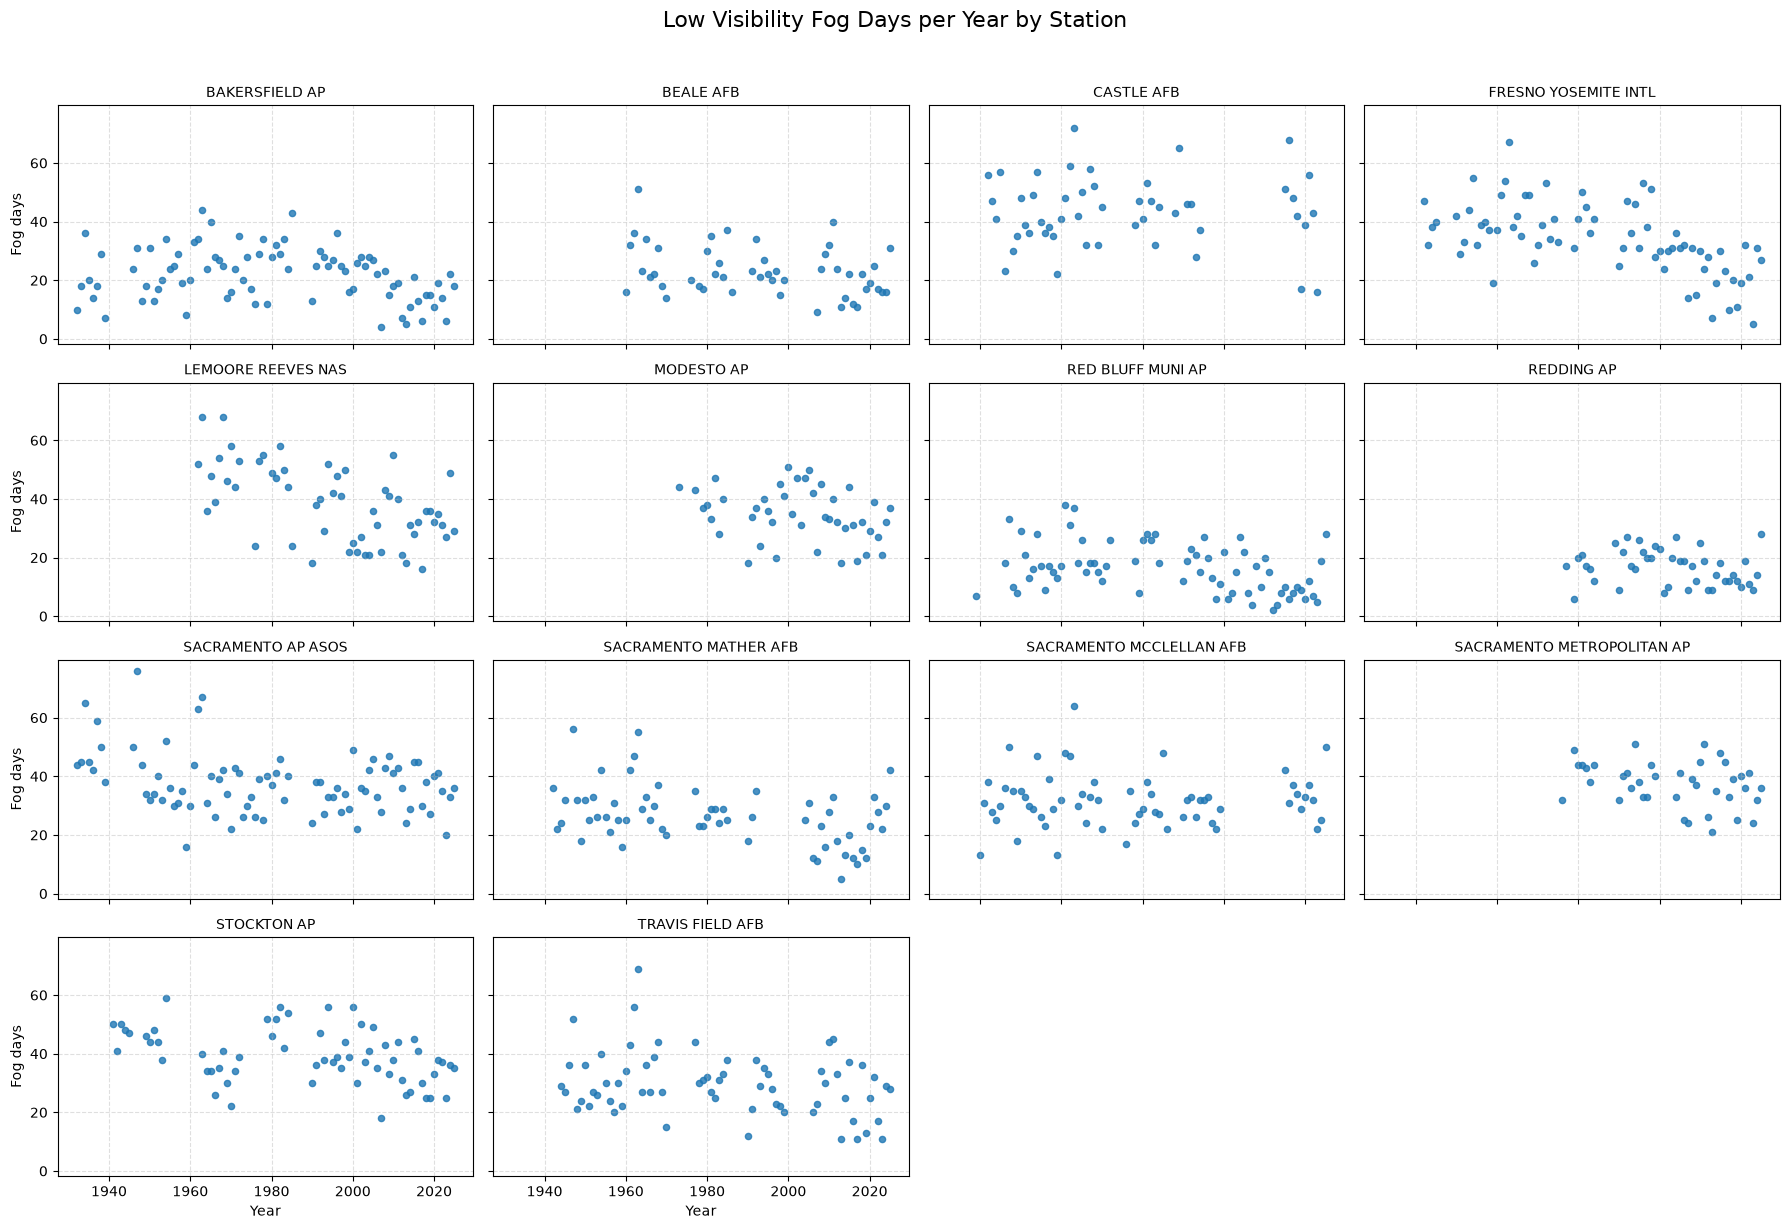

In [18]:

stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
trend_stats_low_vis = []

for station, station_df in low_vis_fog_days_year.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis = pd.DataFrame(trend_stats_low_vis).sort_values("p_value")

print("Low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis = trend_stats_low_vis[trend_stats_low_vis["trend_significant"]]
print(f"\nStations with significant low-visibility fog-day trends: {len(significant_low_vis)}")
print(significant_low_vis[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis = (
    low_vis_fog_days_year
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis = smf.ols("fog_days ~ year", data=annual_low_vis).fit()

print("\nAnnual aggregated low-visibility fog-day trend summary:")
print(model_annual_low_vis.summary())

Low-visibility fog-day trend statistics by station:
                        STATION  n_obs  min_year  max_year     slope  \
5          FRESNO YOSEMITE INTL     72      1942      2025 -0.280274   
8            LEMOORE REEVES NAS     56      1962      2025 -0.384843   
11    MARYSVILLE AIRPORT (ASOS)     19      2005      2025 -1.130761   
18        SACRAMENTO MATHER AFB     62      1942      2025 -0.149900   
15            RED BLUFF MUNI AP     71      1939      2025 -0.123560   
21                  STOCKTON AP     63      1941      2025 -0.136154   
7          HANFORD MUNICIPAL AP     21      2005      2025 -1.298701   
17           SACRAMENTO AP ASOS     83      1932      2025 -0.123095   
1                     BEALE AFB     49      1960      2025 -0.131709   
22             TRAVIS FIELD AFB     66      1944      2025 -0.114869   
0                BAKERSFIELD AP     84      1932      2025 -0.076860   
20   SACRAMENTO METROPOLITAN AP     39      1976      2025 -0.164190   
13          

In [20]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
0               BAKERSFIELD AP     42      1980      2025 -0.461675  0.078275   
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.621237  0.105596   
12                 STOCKTON AP     41      1980      2025 -0.395599  0.096472   
6            RED BLUFF MUNI AP     41      1980      2025 -0.332091  0.083260   
4           LEMOORE REEVES NAS     42      1980      2025 -0.291976  0.127948   
1                    BEALE AFB     35      1980      2025 -0.181692  0.086352   
7                   REDDING AP     42      1980      2025 -0.136367  0.068051   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.177202  0.089240   
5                   MODESTO AP     41      1980      2025 -0.152616  0.110207   
13            TRAVIS FIELD AFB     36      1980      2025 -0.133569  0.107950   
9        SACRAMENTO MATHER AFB     31      1980

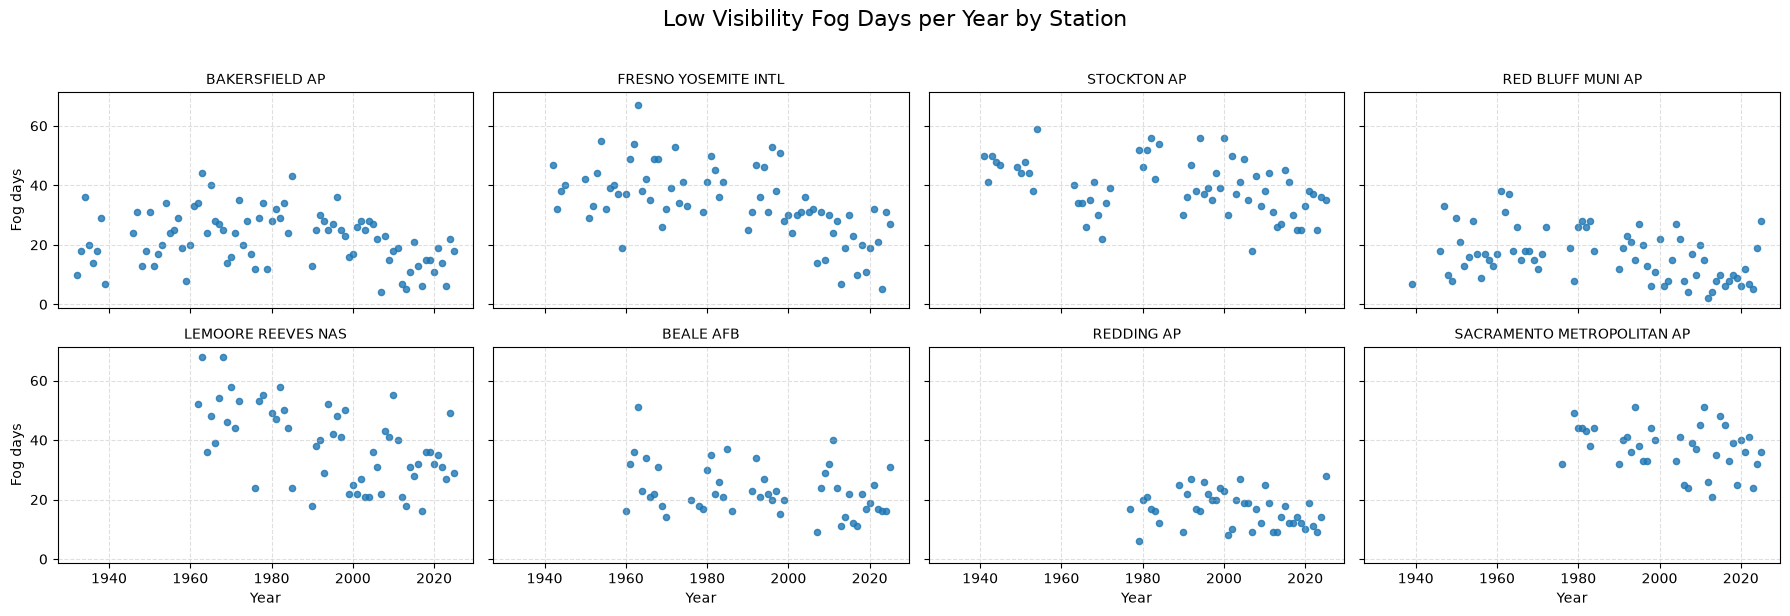

In [24]:
stations = ['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'STOCKTON AP', 'RED BLUFF MUNI AP', 'LEMOORE REEVES NAS', 'BEALE AFB','REDDING AP','SACRAMENTO METROPOLITAN AP']
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

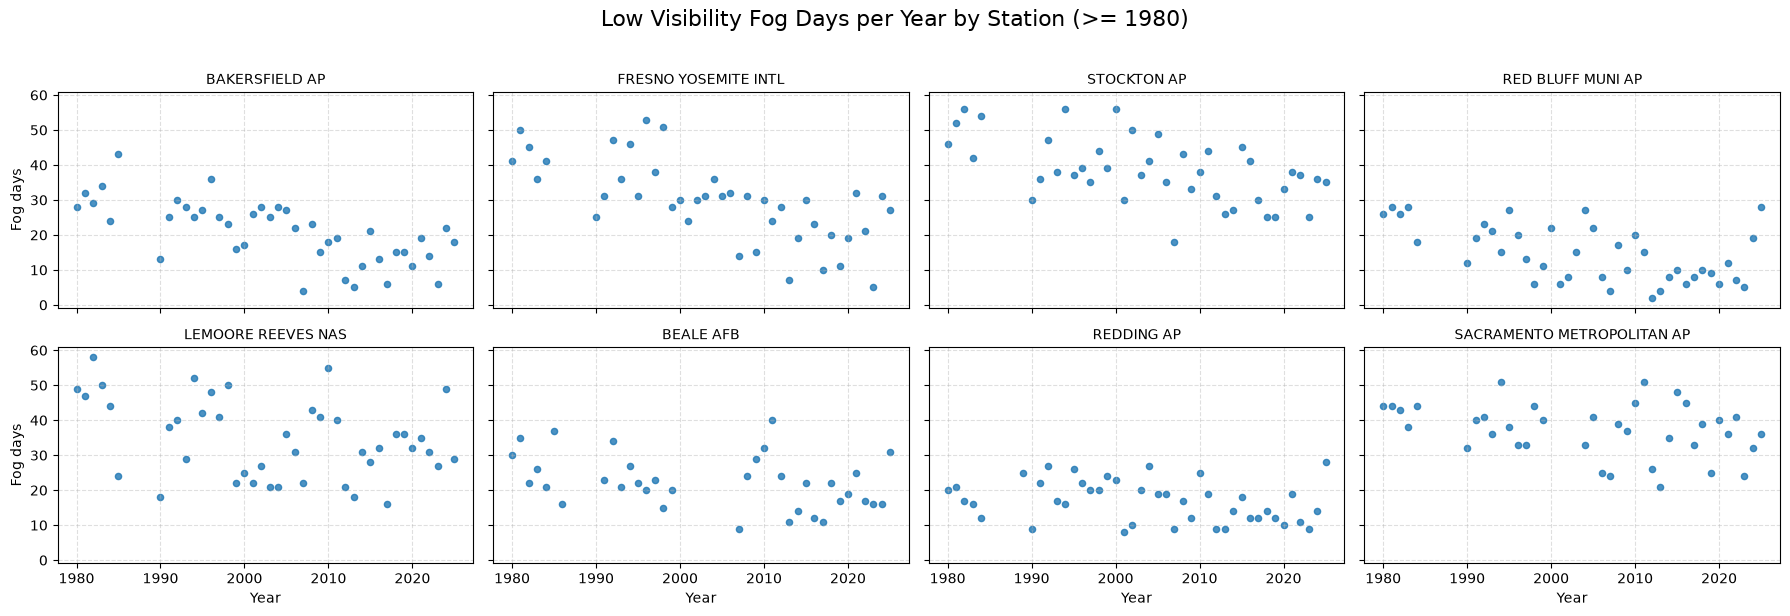

In [25]:
stations = ['BAKERSFIELD AP', 'FRESNO YOSEMITE INTL', 'STOCKTON AP', 'RED BLUFF MUNI AP', 'LEMOORE REEVES NAS', 'BEALE AFB','REDDING AP','SACRAMENTO METROPOLITAN AP']
plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] >= 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (>= 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Filter for low visibility fog days before 1980
pre1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] < 1980].copy()

trend_stats_low_vis_pre1980 = []

for station, station_df in pre1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_pre1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_pre1980 = pd.DataFrame(trend_stats_low_vis_pre1980).sort_values("p_value")

print("Pre-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_pre1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_pre1980 = trend_stats_low_vis_pre1980[trend_stats_low_vis_pre1980["trend_significant"]]
print(f"\nStations with significant pre-1980 low-visibility fog-day trends: {len(significant_low_vis_pre1980)}")
print(significant_low_vis_pre1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_pre1980 = (
    pre1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_pre1980 = smf.ols("fog_days ~ year", data=annual_low_vis_pre1980).fit()

print("\nAnnual aggregated pre-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_pre1980.summary())

Pre-1980 low-visibility fog-day trend statistics by station:
                     STATION  n_obs  min_year  max_year     slope  slope_se  \
7         SACRAMENTO AP ASOS     42      1932      1979 -0.394092  0.127888   
10               STOCKTON AP     22      1941      1979 -0.411043  0.146138   
1                  BEALE AFB     14      1960      1979 -0.826087  0.420149   
0             BAKERSFIELD AP     42      1932      1979  0.120979  0.099823   
5                 MODESTO AP      3      1973      1979 -1.035714  0.680449   
11          TRAVIS FIELD AFB     30      1944      1979  0.157982  0.221459   
4         LEMOORE REEVES NAS     14      1962      1978 -0.416187  0.650106   
8      SACRAMENTO MATHER AFB     31      1942      1979 -0.084396  0.177047   
2                 CASTLE AFB     30      1942      1979  0.098157  0.213369   
6          RED BLUFF MUNI AP     30      1939      1979  0.041491  0.162798   
9   SACRAMENTO MCCLELLAN AFB     35      1940      1979 -0.019199  0.1

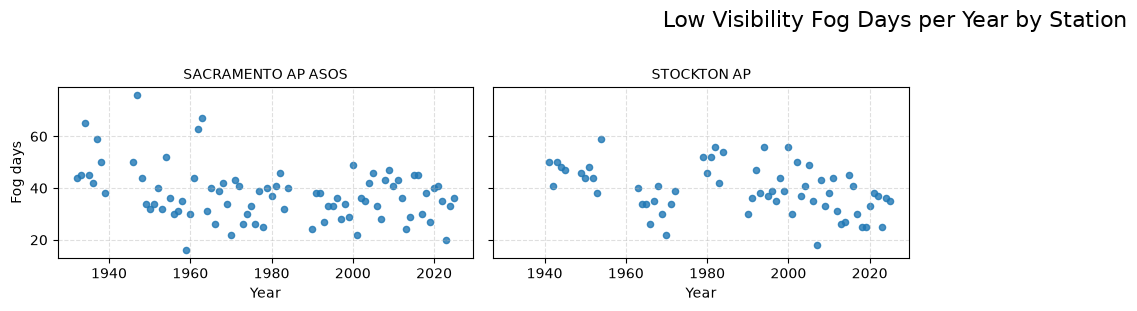

In [28]:
stations = ['SACRAMENTO AP ASOS','STOCKTON AP']
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

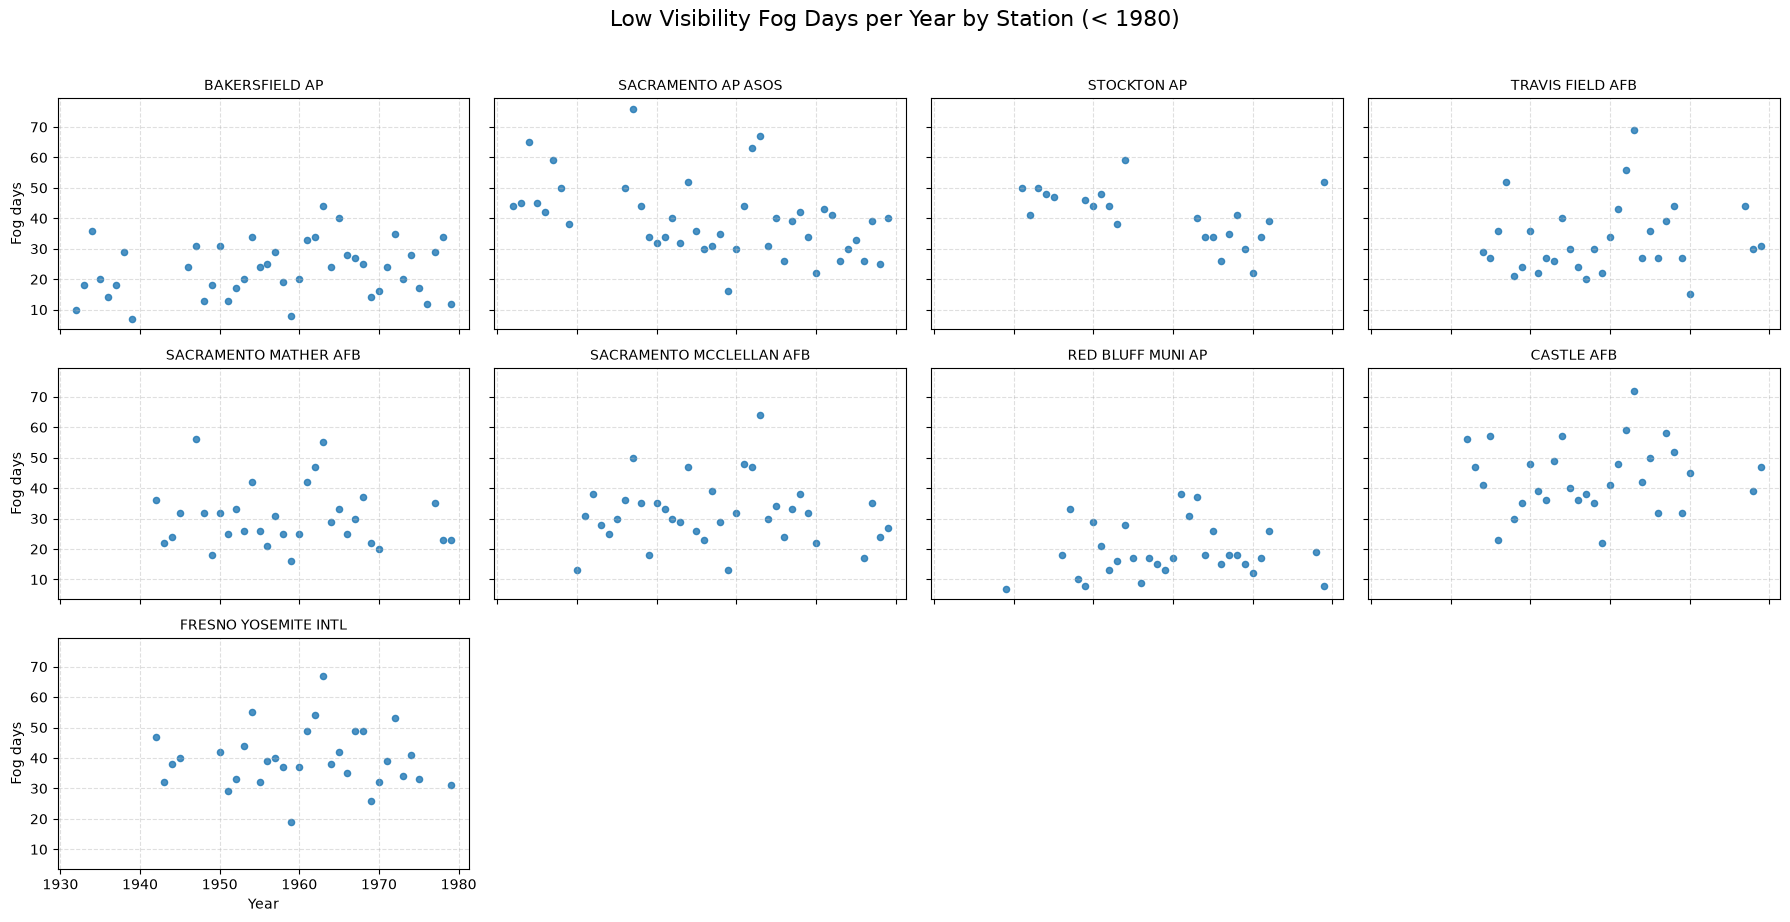

In [30]:
stations = ['BAKERSFIELD AP', 'SACRAMENTO AP ASOS', 'STOCKTON AP','TRAVIS FIELD AFB','SACRAMENTO MATHER AFB','SACRAMENTO MCCLELLAN AFB','RED BLUFF MUNI AP','CASTLE AFB','FRESNO YOSEMITE INTL']
plot_df = low_vis_fog_days_year_filtered[
    (low_vis_fog_days_year_filtered['STATION'].isin(stations)) &
    (low_vis_fog_days_year_filtered['year'] < 1980)
].copy()

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = plot_df[plot_df['STATION'] == station].sort_values('year')
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station (< 1980)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

          STATION  year  fog_days  avg_event_duration_hours  total_events  \
0  BAKERSFIELD AP  1932        10                  2.400000            11   
1  BAKERSFIELD AP  1933        18                  2.261973            40   
2  BAKERSFIELD AP  1934        36                  2.530311            63   
3  BAKERSFIELD AP  1935        20                  2.317972            40   
4  BAKERSFIELD AP  1936        14                  2.676768            20   

   avg_monthly_low_vis_days  
0                  3.333333  
1                  6.000000  
2                  7.200000  
3                  5.000000  
4                  2.333333  


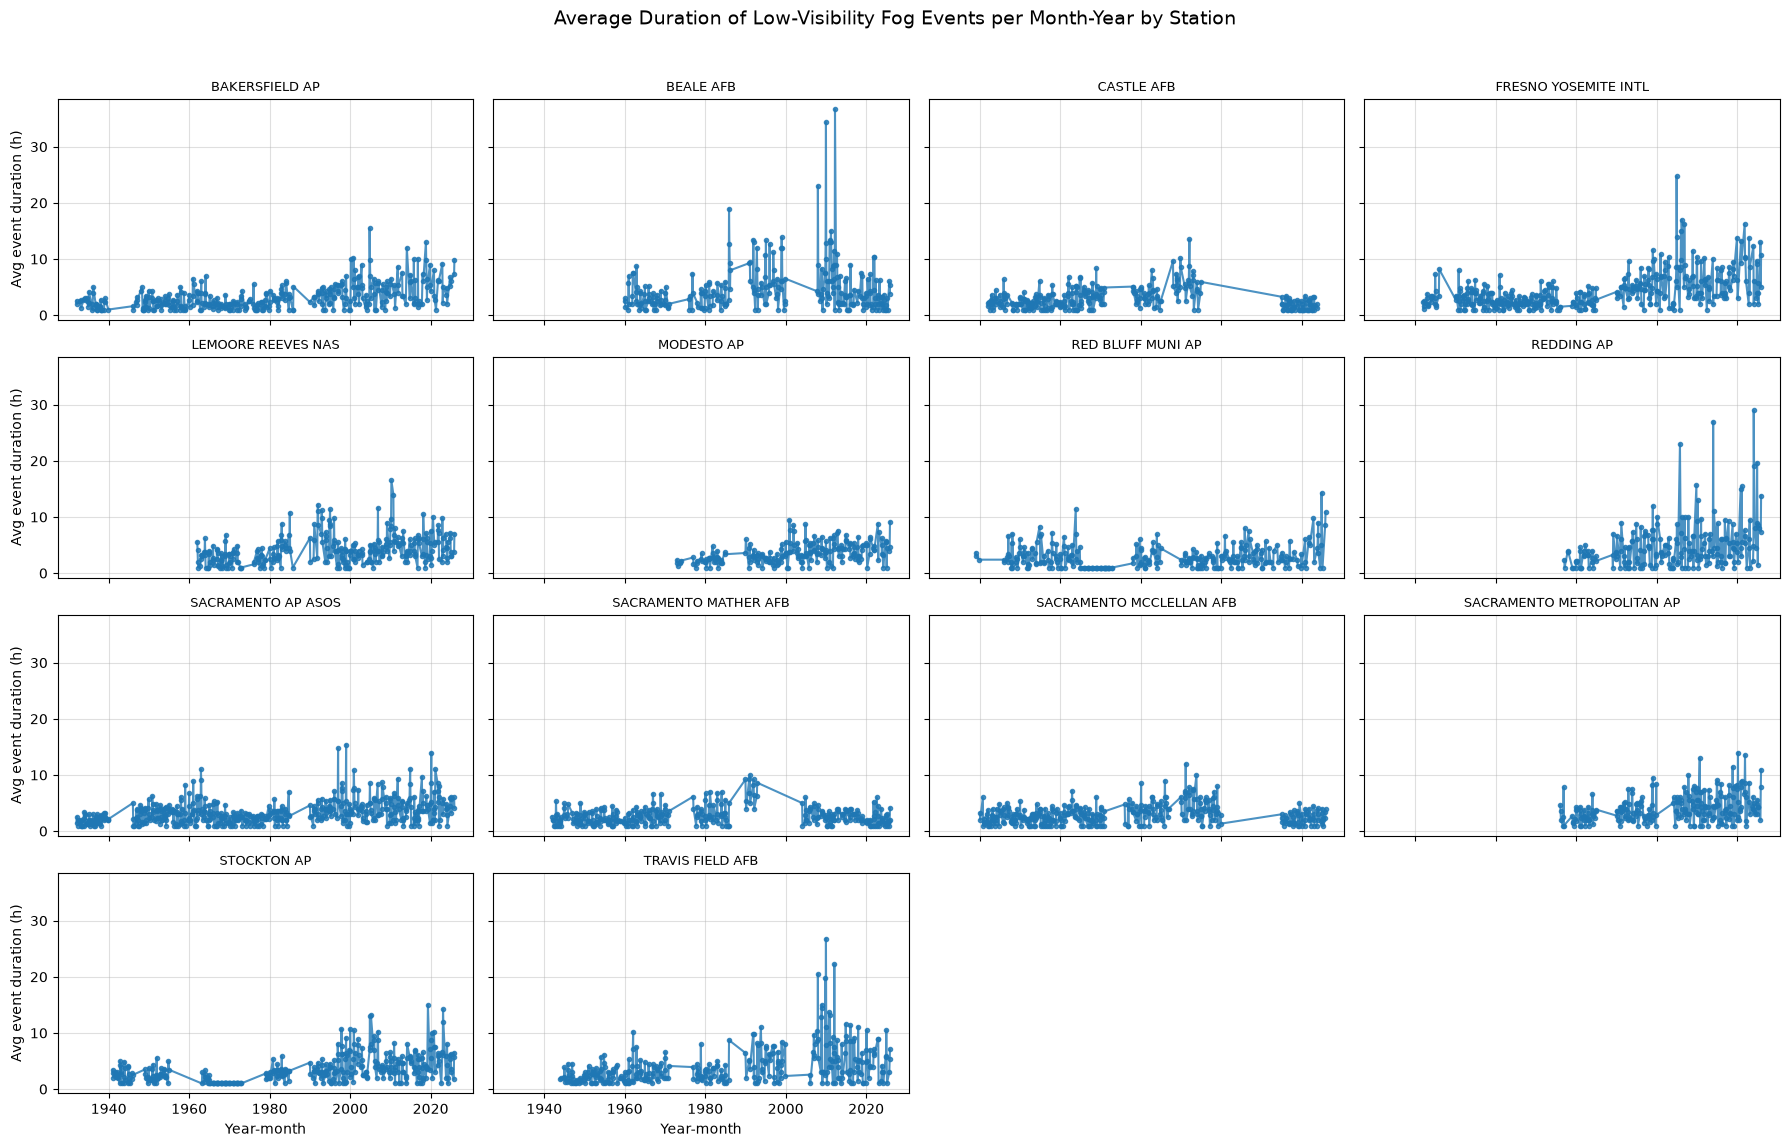

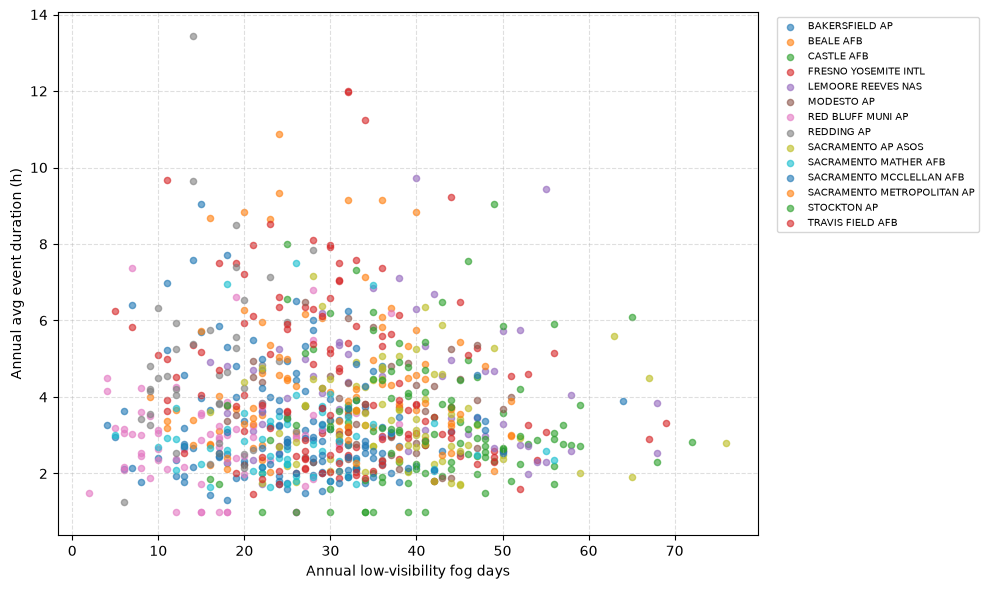

In [33]:
# compute low-visibility fog events from hourly CV_rows observations
low_vis_events = low_vis_rows.copy()
if low_vis_events["DATE"].dtype == object:
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"])

low_vis_events = low_vis_events.sort_values(["STATION", "DATE"])
# ensure DATE is datetime (handles object, pandas string dtype, etc.)
if not pd.api.types.is_datetime64_any_dtype(low_vis_events["DATE"]):
    low_vis_events["DATE"] = pd.to_datetime(low_vis_events["DATE"], errors="coerce")

# compute time difference within each station; treat first obs as a large gap
low_vis_events["time_diff"] = low_vis_events.groupby("STATION")["DATE"].diff()
low_vis_events["time_diff"] = low_vis_events["time_diff"].fillna(pd.Timedelta(hours=999))
low_vis_events["new_event"] = low_vis_events["time_diff"] > pd.Timedelta(hours=1.5)
low_vis_events["event_id"] = low_vis_events.groupby("STATION")["new_event"].cumsum()

event_summary = (
    low_vis_events
    .groupby(["STATION", "event_id"], as_index=False)
    .agg(
        start=("DATE", "min"),
        end=("DATE", "max"),
        year=("year", "first"),
        month=("month", "first"),
        duration_hours=("event_id", "size"),
    )
)

event_summary["year_month"] = pd.to_datetime(
    dict(year=event_summary["year"], month=event_summary["month"], day=1)
)

monthly_low_vis_days = (
    low_vis_events
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "low_vis_days"})
)

event_monthly = (
    event_summary
    .groupby(["STATION", "year", "month"], as_index=False)
    .agg(
        avg_event_duration_hours=("duration_hours", "mean"),
        n_events=("duration_hours", "size"),
    )
    .merge(monthly_low_vis_days, on=["STATION", "year", "month"], how="left")
)

event_monthly["year_month"] = pd.to_datetime(
    dict(year=event_monthly["year"], month=event_monthly["month"], day=1)
)

annual_event_stats = (
    event_monthly
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        avg_event_duration_hours=("avg_event_duration_hours", "mean"),
        total_events=("n_events", "sum"),
        avg_monthly_low_vis_days=("low_vis_days", "mean"),
    )
)

annual_compare = low_vis_fog_days_year.merge(
    annual_event_stats,
    on=["STATION", "year"],
    how="left"
)

print(annual_compare.head())

plot_stations = stations_with_30_years.tolist()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    station_df = event_monthly[event_monthly["STATION"] == station].sort_values("year_month")
    ax.plot(
        station_df["year_month"],
        station_df["avg_event_duration_hours"],
        marker="o",
        linestyle="-",
        markersize=3,
        alpha=0.8,
    )
    ax.set_title(station, fontsize=9)
    ax.grid(True, alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year-month")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Duration of Low-Visibility Fog Events per Month-Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for station in plot_stations:
    station_ann = annual_compare[annual_compare["STATION"] == station]
    ax.scatter(
        station_ann["fog_days"],
        station_ann["avg_event_duration_hours"],
        s=20,
        alpha=0.6,
        label=station,
    )

ax.set_xlabel("Annual low-visibility fog days")
ax.set_ylabel("Annual avg event duration (h)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize="x-small", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

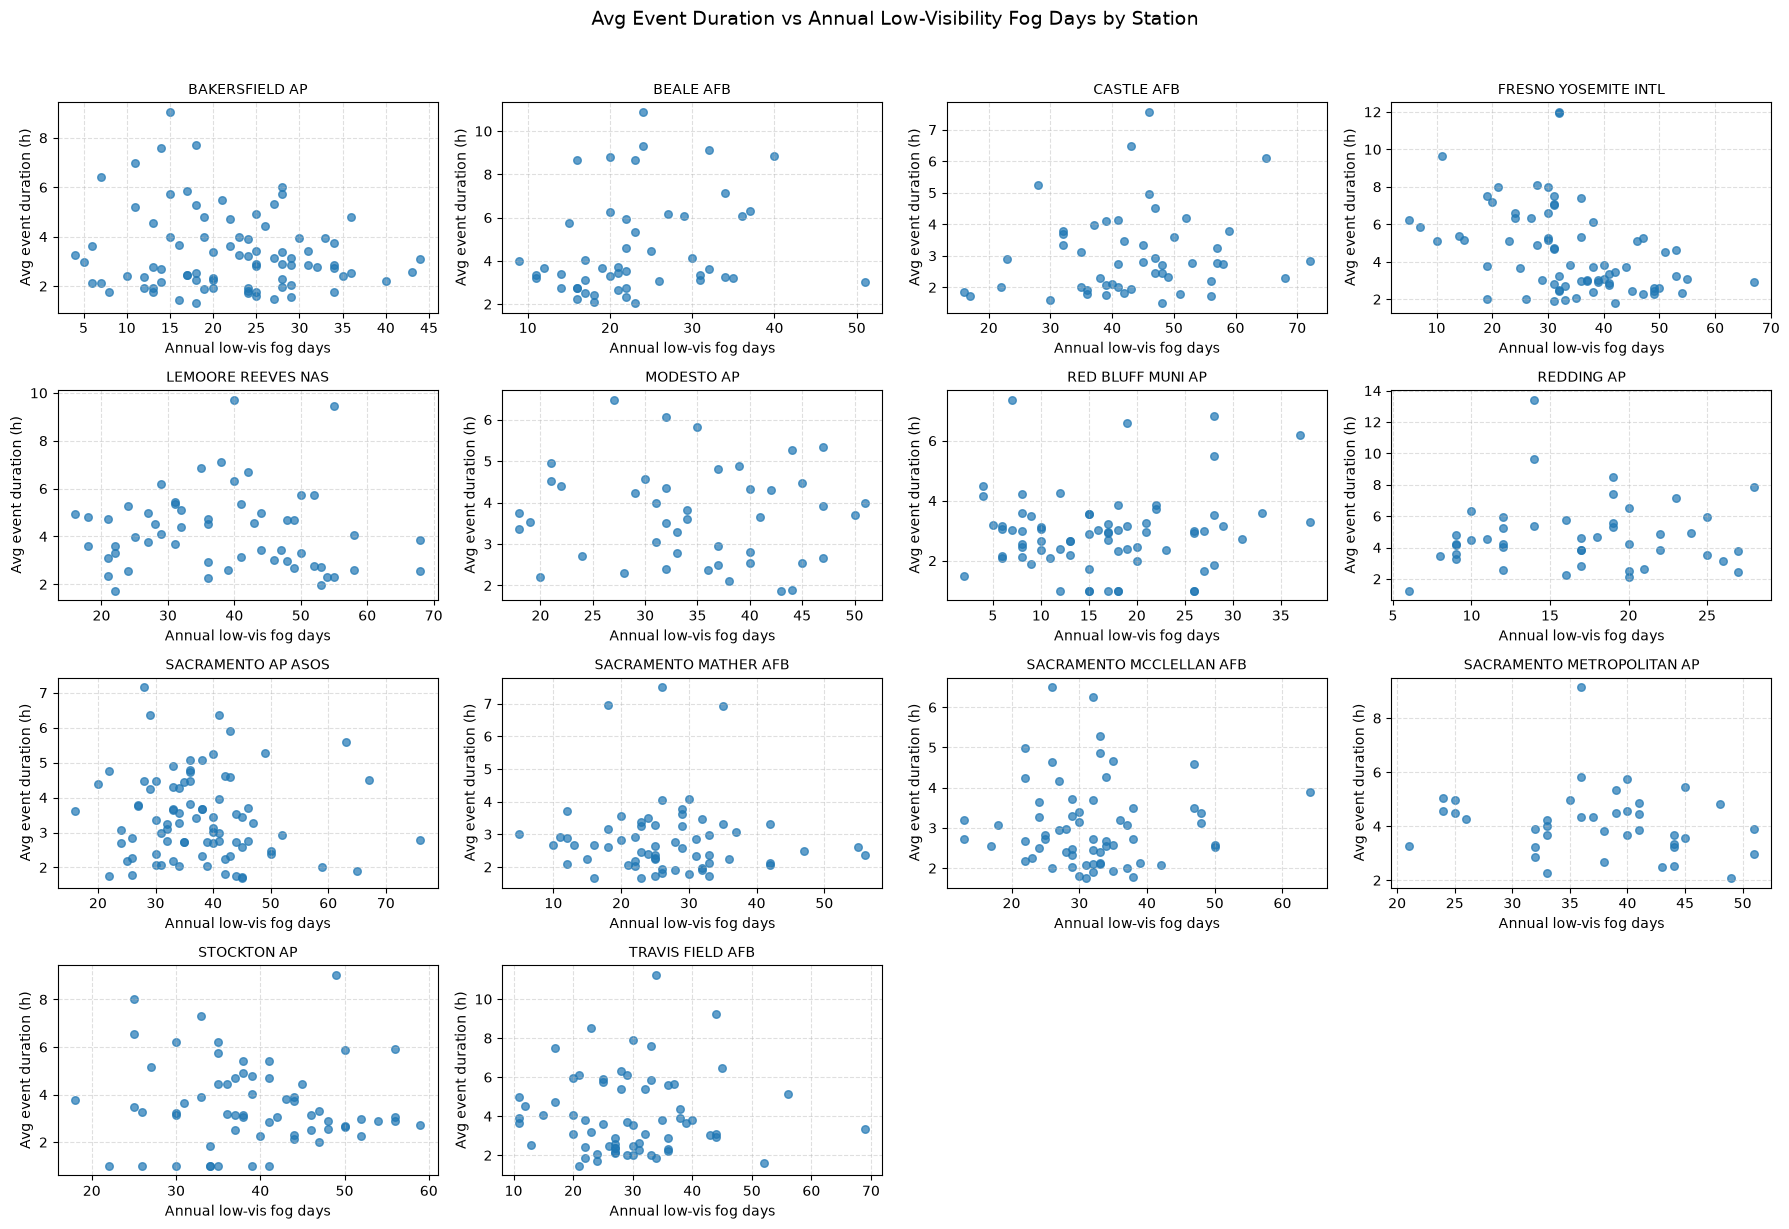

In [34]:
plot_stations = annual_compare[annual_compare["STATION"].isin(stations_with_30_years)]["STATION"].unique()
n_stations = len(plot_stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(plot_stations):
    ax = axes[idx]
    station_ann = annual_compare[
        (annual_compare["STATION"] == station)
        & (annual_compare["avg_event_duration_hours"] > 0)
    ].sort_values("year")

    if station_ann.empty:
        ax.set_visible(False)
        continue

    ax.scatter(
        station_ann["fog_days"],
        station_ann["avg_event_duration_hours"],
        s=30,
        alpha=0.7,
    )
    ax.set_title(station, fontsize=10)
    ax.set_xlabel("Annual low-vis fog days")
    ax.set_ylabel("Avg event duration (h)")
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Avg Event Duration vs Annual Low-Visibility Fog Days by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

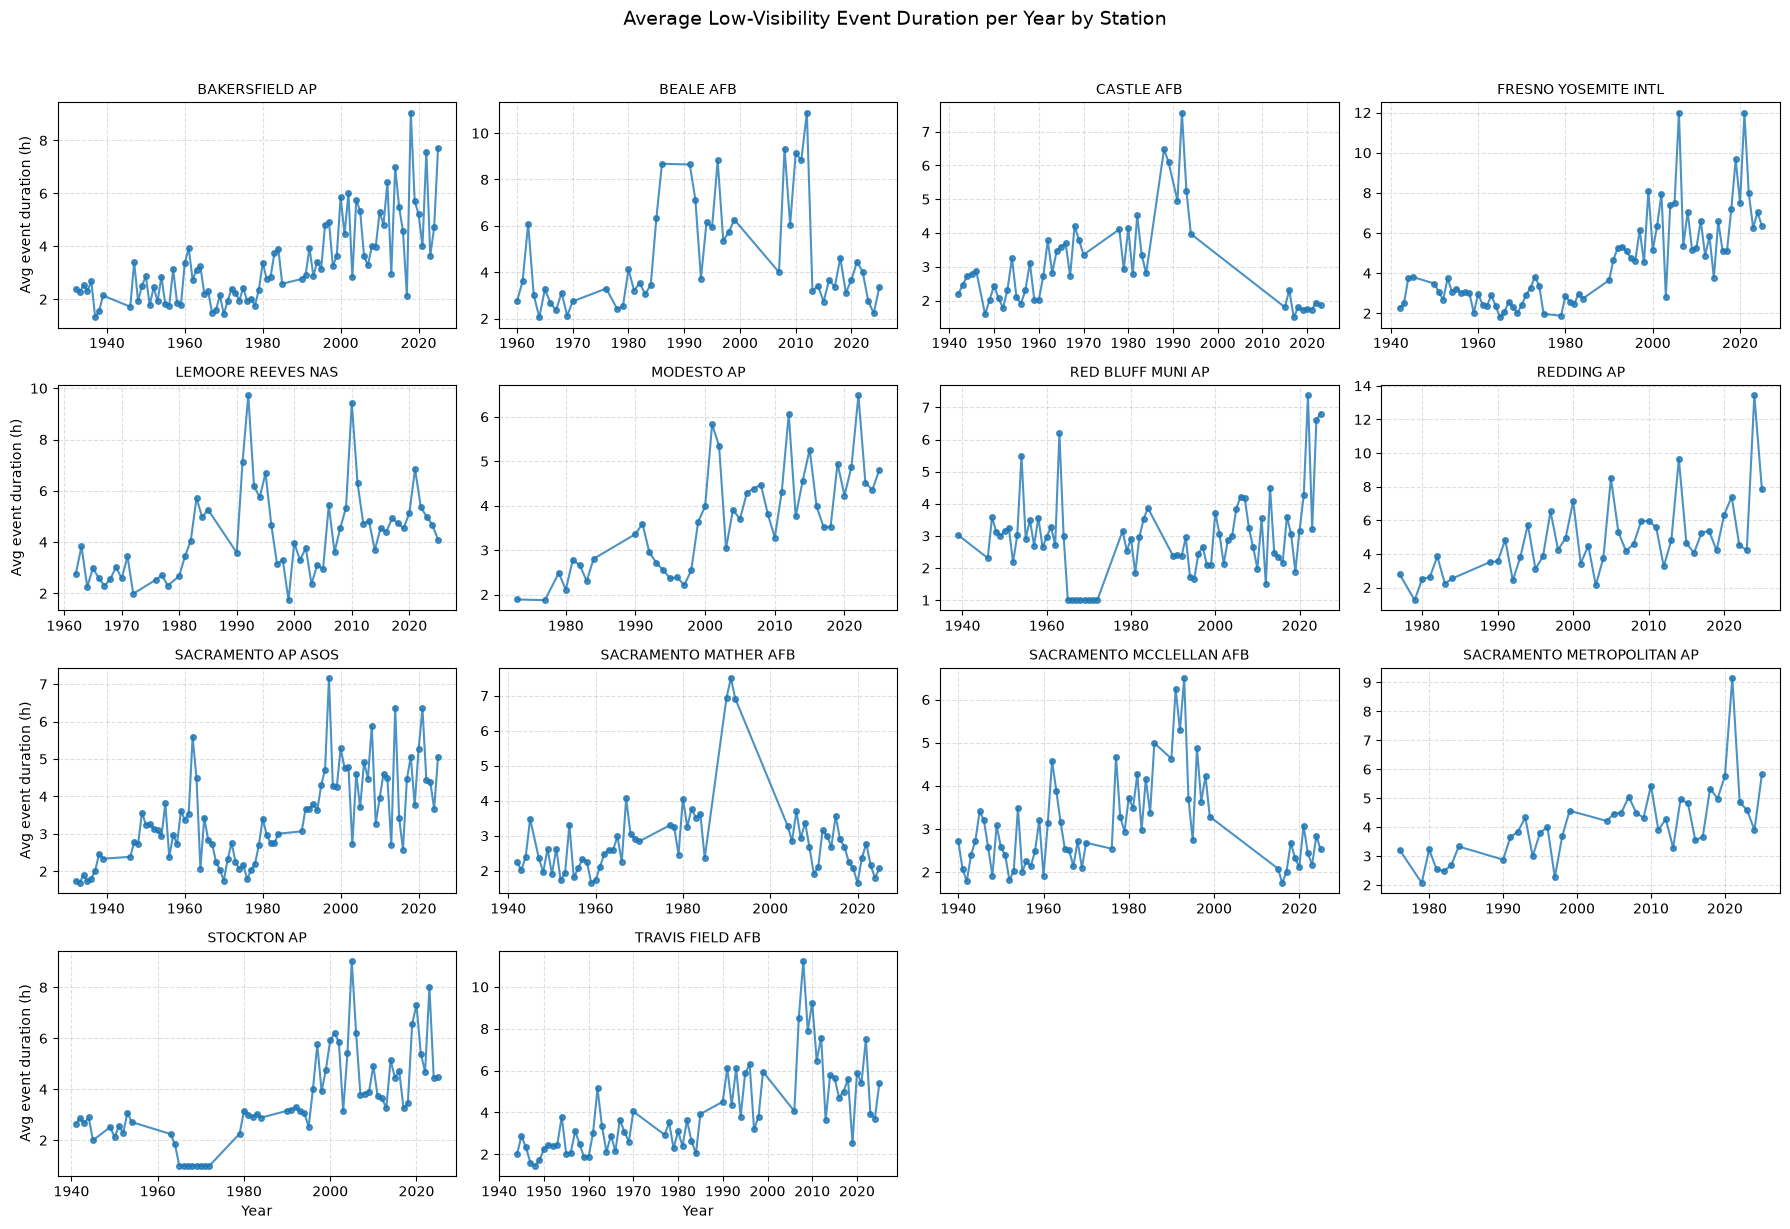

In [37]:
stations = stations_with_30_years.tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=False, sharey=False)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_ann = annual_compare[annual_compare["STATION"] == station].sort_values("year")
    if station_ann.empty or station_ann["avg_event_duration_hours"].isna().all():
        ax.set_visible(False)
        continue
    ax.plot(station_ann["year"], station_ann["avg_event_duration_hours"], marker="o", linestyle="-", markersize=4, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    if idx % ncols == 0:
        ax.set_ylabel("Avg event duration (h)")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Low-Visibility Event Duration per Year by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# exclude zero or missing monthly values and recompute annual summaries
event_monthly_nozeros = event_monthly[
    (event_monthly['avg_event_duration_hours'].fillna(0) > 0) &
    (event_monthly['n_events'].fillna(0) > 0) &
    (event_monthly['low_vis_days'].fillna(0) > 0)
].copy()

annual_event_stats_nozeros = (
    event_monthly_nozeros
    .groupby(['STATION', 'year'], as_index=False)
    .agg(
        avg_event_duration_hours=('avg_event_duration_hours', 'mean'),
        total_events=('n_events', 'sum'),
        avg_monthly_low_vis_days=('low_vis_days', 'mean'),
    )
)

annual_compare_nozeros = low_vis_fog_days_year.merge(
    annual_event_stats_nozeros,
    on=['STATION', 'year'],
    how='left'
)

print("event_monthly_nozeros:", event_monthly_nozeros.shape)
print("annual_event_stats_nozeros:", annual_event_stats_nozeros.shape)
print("annual_compare_nozeros:", annual_compare_nozeros.shape)
annual_compare_nozeros.head()

event_monthly_nozeros: (5552, 7)
annual_event_stats_nozeros: (1054, 5)
annual_compare_nozeros: (1054, 6)


,STATION,year,fog_days,avg_event_duration_hours,total_events,avg_monthly_low_vis_days
0,BAKERSFIELD AP,1932,10,2.400000,11,3.333333
1,BAKERSFIELD AP,1933,18,2.261973,40,6.000000
2,BAKERSFIELD AP,1934,36,2.530311,63,7.200000
3,BAKERSFIELD AP,1935,20,2.317972,40,5.000000
4,BAKERSFIELD AP,1936,14,2.676768,20,2.333333


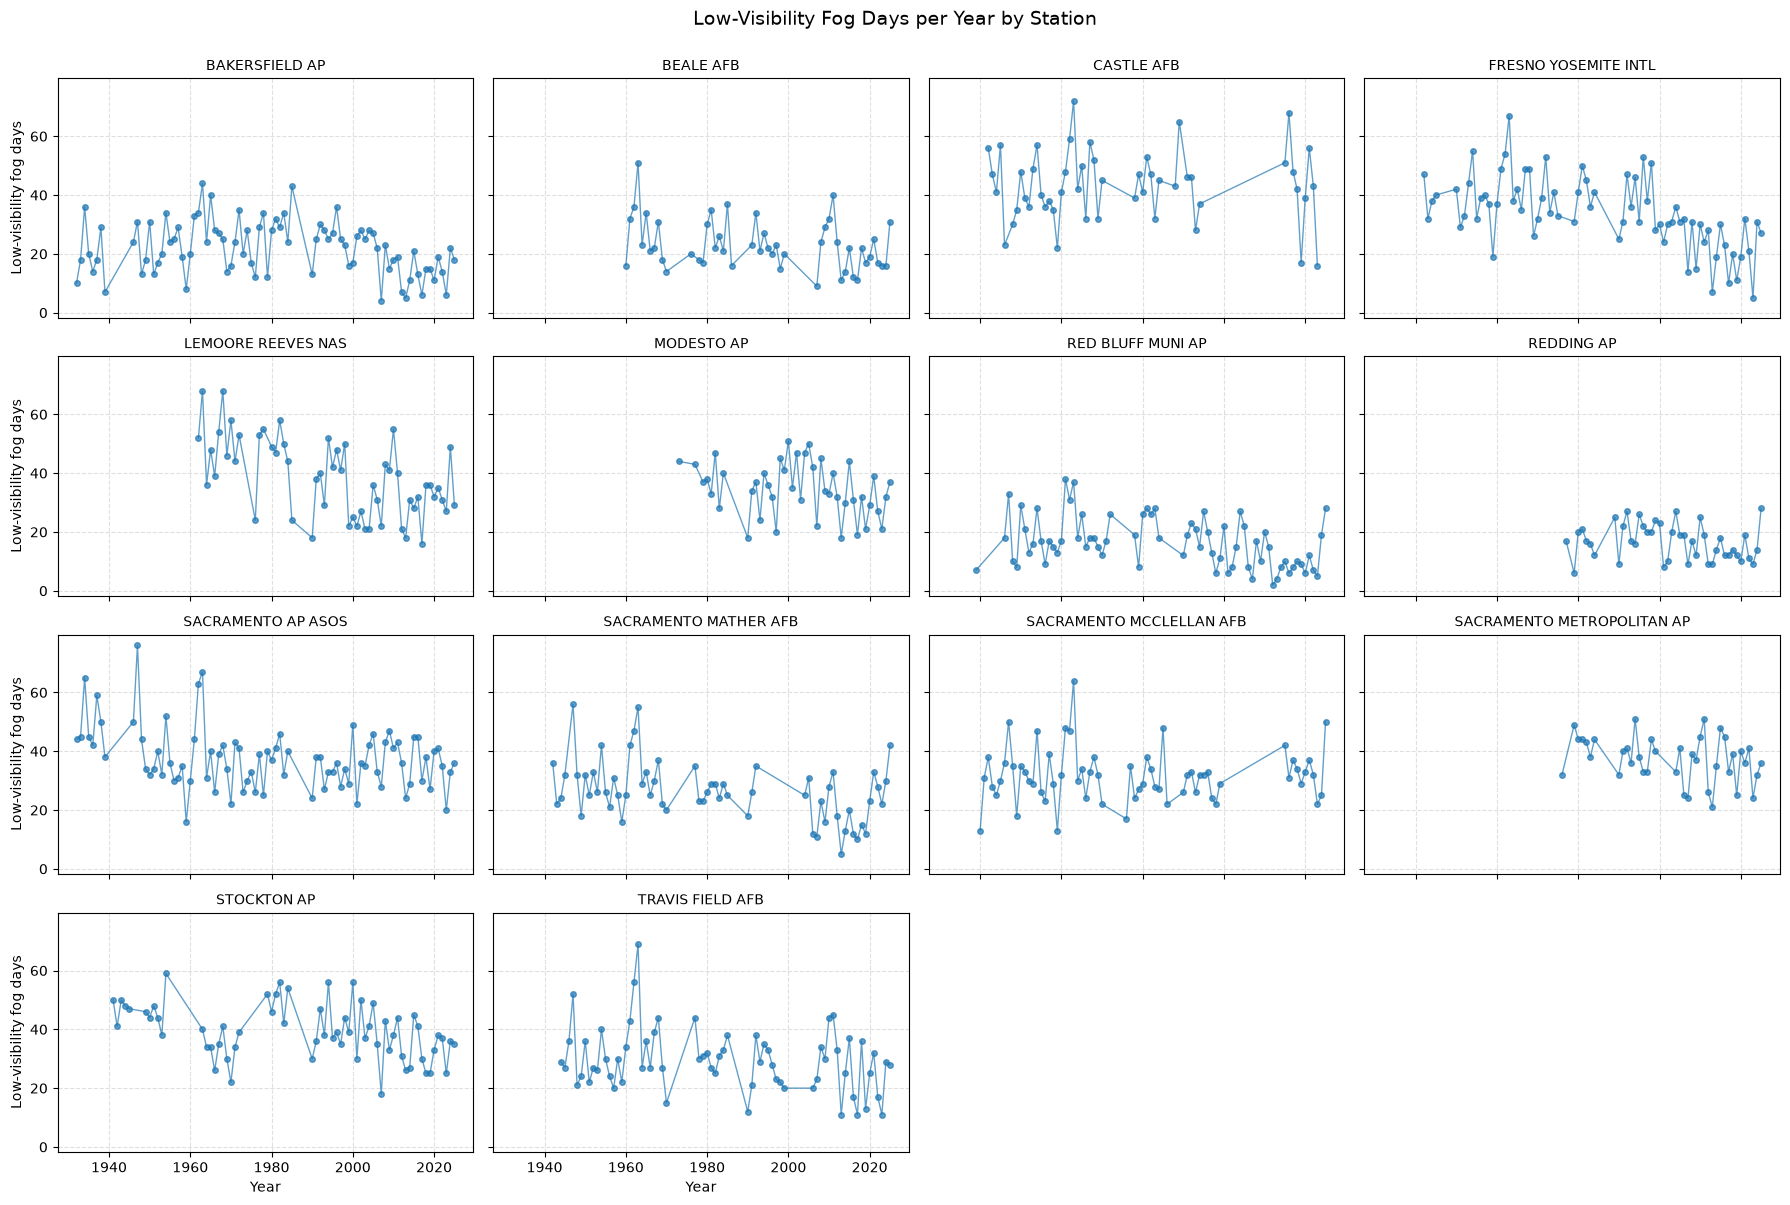

In [38]:
# Create a comprehensive plot of low-visibility fog days per station per year
stations = stations_with_30_years.tolist()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station].sort_values('year')
    ax.plot(station_df['year'], station_df['fog_days'], marker='o', linestyle='-', markersize=4, alpha=0.7, linewidth=1)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel('Low-visibility fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low-Visibility Fog Days per Year by Station', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()